# Using `.merge()` with dataframes and geodataframes

The goal of this lesson is to learn how to combine data from two tables using .merge() — a fundamental operation in data analysis.

This is useful when you have:

* A main dataset (e.g., city boundaries)
* A reference table (e.g., city population or region codes)
* And you want to enrich your main dataset with that reference information.

In [ ]:
# Import necessary libraries
import pandas as pd

In [ ]:
# Import 3 .csv files containing data about NWS WFOs
nws1 = pd.read_csv('nws1.csv')
nws2 = pd.read_csv('nws2.csv')
nws3 = pd.read_csv('nws3.csv')

In [ ]:
# Examine the nws1 dataframe
nws1

In [ ]:
# Examine the nws2 dataframe
nws2

In [ ]:
# Examine the nws3 dataframe
nws3

# Types of merges

Note: In this context, the words 'join' and 'merge' will be used interchangeably. If you have any experience with SQL (or go on to learn it), you will see that 'join' is commonly used to describe what operation we are doing.

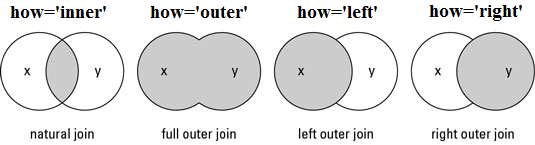

### Join (merge) types explained

| Join Type | Keeps Rows From | Includes Non-Matches?        | Analogy            |
| --------- | --------------- | ---------------------------- | ------------------ |
| `inner`   | Both tables     | ❌ No (only matches)          | Intersection (∩)   |
| `left`    | Left table      | ✅ Yes (left-only rows kept)  | Left-biased merge  |
| `right`   | Right table     | ✅ Yes (right-only rows kept) | Right-biased merge |
| `outer`   | Both tables     | ✅ Yes (all rows from both)   | Union (∪)          |

## Practice with merging 2 Pandas dataframes

In [ ]:
# Table 1 with city data
cities = pd.DataFrame({'city_id': [1, 2, 3], 'city_name': ['New York', 'Los Angeles', 'Chicago']})
# Table 2 with population data (the reference table)
pop_info = pd.DataFrame({'city_id': [1, 2, 3], 'population': [8419600, 3980400, 2716000]})

# Print both tables to examine
print(cities)
print(pop_info)

In [ ]:
# To merge these two dataframes (and attach the population number to each city), I need to use:
new_df = cities.merge(pop_info, on='city_id') # The on= keyword tells Pandas which column to merge on
# Print resulting dataframe to verify the merge worked
new_df

In [ ]:
# Let's attempt to merge our nws1 and nws3 dataframes and see what happens
merged_nws = nws1.merge(nws3, on='WFO', how='left') # The how= keyword tells Pandas which type of join to do. By default, an inner join will be performed


## Example 1

List the addresses and number of counties for WFOs in the southern region only

In [ ]:
# Step 1: Merge the two dataframes

# Step 2: Filter the resulting dataframe to only show WFOs in the Southern region


## Example 2

What if we need to merge more than 2 tables?

In [ ]:
# Combine all 3 NWS info tables and print the resulting dataframe


## Plotting NWS WFO by region

In [ ]:
import geopandas as gpd
wfo_boundaries = gpd.read_file('w_05mr24(2)(1).zip')
wfo_boundaries

In [ ]:
# Import necessary plotting libraries
# Note: In an actual script, all these imports would be located with any other imports at the beginning of the script
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
# Create figure object
fig = plt.figure(1, figsize=(14,12))
# Create axis object
ax = plt.subplot(1,1,1,projection=ccrs.PlateCarree())
# Set the extent of the axis to only show the continental U.S.
ax.set_extent([-130, -65, 20, 55], ccrs.PlateCarree())
# Generate plot of the geodataframe of WFO boundaries and **add it to the axis object already created**


## Example 3

Create a plot of the NWS WFOs in the southern region and color the polygon based on the number of counties the WFO has.

This is going to require the merging of one of our nws dataframes with our nws boundaries geodataframe!

In [ ]:
# Step 1: Merge the necessary dataframes and geodataframes

# NOTE: When merging geodataframes with dataframes, ALWAYS use the geodataframe as the left table so that the geometry is preserved! We have to have the geometry in order to plot!

# Filter the resulting dataframe to only show WFOs in the southern region


In [ ]:
# Generate plot
# Create figure object
fig = plt.figure(1, figsize=(14,12))
# Create axis object
ax = plt.subplot(1,1,1,projection=ccrs.PlateCarree())
# Generate plot of the geodataframe of WFO boundaries and **add it to the axis object already created**
